# 03 — Model Experiment: Tuning & Evaluasi

Notebook ini melakukan:
1. Load semua artefak hasil preprocessing
2. Uji masing-masing metode (CBF, CF, KB) secara individual
3. Grid search bobot hybrid terbaik
4. Evaluasi Precision@K dan Recall@K
5. Simpan hasil evaluasi dan bobot terbaik

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sys.path.insert(0, '..')

from config import (
    PROC_FILES, MODEL_FILES, SENSOR_COLS,
    COMPONENT_COLS, EVAL_K_VALUES, DEFAULT_WEIGHTS
)
from src.cbf        import load_similarity_matrix, cbf_recommend
from src.cf         import compute_cf_similarity, cf_recommend, get_cf_explanation
from src.kb         import kb_recommend, get_kb_alerts
from src.hybrid     import hybrid_recommend, save_weights
from src.evaluation import load_ground_truth, precision_at_k, recall_at_k, evaluate_system, print_evaluation_summary

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
print('Import selesai.')

Import selesai.


## 1. Load artefak

In [2]:
merged      = pd.read_parquet(PROC_FILES['merged'])
interaction = pd.read_parquet(PROC_FILES['interaction'])
sensor_norm = pd.read_parquet(PROC_FILES['sensor_norm'])

sim_cbf = load_similarity_matrix()

cf_path = MODEL_FILES['sim_matrix'].parent / 'cf_similarity_matrix.npy'
cf_idx  = np.load(cf_path.with_suffix('.index.npy'))
sim_cf  = pd.DataFrame(np.load(cf_path), index=cf_idx, columns=cf_idx)

ground_truth = load_ground_truth()
all_machine_ids = sorted(merged['machineID'].unique().tolist())

print(f'Merged shape     : {merged.shape}')
print(f'Interaction shape: {interaction.shape}')
print(f'CBF sim shape    : {sim_cbf.shape}')
print(f'CF sim shape     : {sim_cf.shape}')
print(f'Ground truth     : {len(ground_truth)} mesin')
print(f'Total mesin      : {len(all_machine_ids)}')

Merged shape     : (876100, 25)
Interaction shape: (100, 4)
CBF sim shape    : (100, 100)
CF sim shape     : (100, 100)
Ground truth     : 98 mesin
Total mesin      : 100


## 2. Helper: ambil sensor & days_since terkini per mesin

In [3]:
def get_latest_state(machine_id: int):
    """Ambil nilai sensor dan days_since terkini untuk satu mesin."""
    latest = (
        merged[merged['machineID'] == machine_id]
        .sort_values('datetime')
        .iloc[-1]
    )
    sensor = {col: float(latest[col]) for col in SENSOR_COLS if col in latest.index}
    days   = {
        comp: float(latest.get(f'days_since_{comp}', 9999))
        for comp in COMPONENT_COLS
    }
    return sensor, days

# Test dengan mesin 1
sensor_1, days_1 = get_latest_state(1)
print('Sensor terkini mesin 1:', sensor_1)
print('Days since mesin 1    :', days_1)

Sensor terkini mesin 1: {'volt': 191.873171142148, 'rotate': 382.736625649486, 'pressure': 100.893691098222, 'vibration': 37.9402195210172}
Days since mesin 1    : {'comp1': 1.0, 'comp2': 46.0, 'comp3': 31.0, 'comp4': 16.0}


## 3. Uji masing-masing metode secara individual

In [4]:
machine_id = 1
sensor, days = get_latest_state(machine_id)

cbf_scores = cbf_recommend(machine_id, interaction, sim_cbf)
cf_scores  = cf_recommend(machine_id, interaction, sim_cf)
kb_scores  = kb_recommend(machine_id, sensor, days)

comparison = pd.DataFrame({
    'CBF' : cbf_scores,
    'CF'  : cf_scores,
    'KB'  : kb_scores,
})
print(f'\nSkor individual untuk mesin {machine_id}:')
print(comparison)
print(f'\nGround truth mesin {machine_id}: {ground_truth.get(machine_id, set())}')


Skor individual untuk mesin 1:
         CBF     CF     KB
comp1 1.0000 0.9661 0.0000
comp2 0.7758 0.8473 0.0000
comp3 0.5517 0.6270 0.0000
comp4 0.8276 1.0000 0.0000

Ground truth mesin 1: {'comp2', 'comp1', 'comp4'}


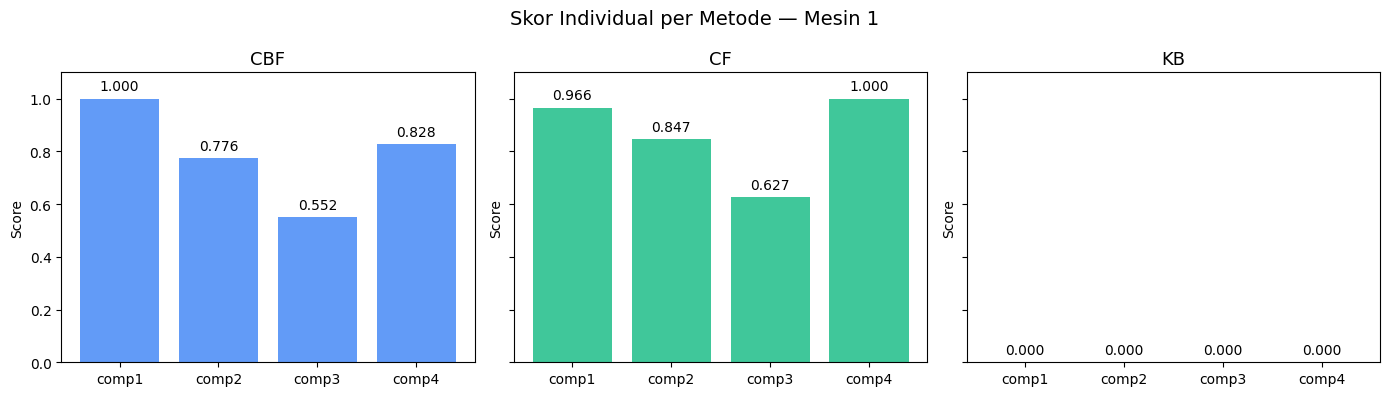

In [5]:
# Visualisasi perbandingan skor 3 metode
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ['#3B82F6', '#10B981', '#F59E0B']
for ax, (col, color) in zip(axes, zip(['CBF', 'CF', 'KB'], colors)):
    bars = ax.bar(comparison.index, comparison[col], color=color, alpha=0.8)
    ax.set_title(col, fontsize=13)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, comparison[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.suptitle(f'Skor Individual per Metode — Mesin {machine_id}', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Evaluasi metode individual (Precision@K dan Recall@K)

In [6]:
def evaluate_single_method(method_name, score_fn, k_values=EVAL_K_VALUES):
    """Evaluasi satu metode untuk semua mesin."""
    rows = []
    for mid in all_machine_ids:
        sensor, days = get_latest_state(mid)
        try:
            if method_name == 'KB':
                scores = score_fn(mid, sensor, days)
            elif method_name == 'CBF':
                scores = score_fn(mid, interaction, sim_cbf)
            else:  # CF
                scores = score_fn(mid, interaction, sim_cf)
            rec_list = scores.sort_values(ascending=False).index.tolist()
            for k in k_values:
                p = precision_at_k(mid, rec_list, ground_truth, k)
                r = recall_at_k(mid, rec_list, ground_truth, k)
                f1 = (2*p*r/(p+r)) if (p+r) > 0 else 0
                rows.append({'method': method_name, 'machineID': mid, 'k': k,
                             'precision': p, 'recall': r, 'f1': f1})
        except Exception as e:
            print(f'  Skip mesin {mid}: {e}')
    return pd.DataFrame(rows)

print('Evaluasi CBF...')
eval_cbf = evaluate_single_method('CBF', cbf_recommend)
print('Evaluasi CF...')
eval_cf  = evaluate_single_method('CF',  cf_recommend)
print('Evaluasi KB...')
eval_kb  = evaluate_single_method('KB',  kb_recommend)

eval_individual = pd.concat([eval_cbf, eval_cf, eval_kb])

summary_individual = (
    eval_individual
    .groupby(['method', 'k'])[['precision', 'recall', 'f1']]
    .mean()
    .round(4)
)
print('\nRingkasan evaluasi individual:')
print(summary_individual)

Evaluasi CBF...
Evaluasi CF...
Evaluasi KB...

Ringkasan evaluasi individual:
          precision  recall     f1
method k                          
CBF    1     0.7700  0.3033 0.4243
       3     0.7033  0.8050 0.7320
       5     0.5200  0.9800 0.6646
CF     1     0.8300  0.3400 0.4677
       3     0.7200  0.8300 0.7510
       5     0.5200  0.9800 0.6646
KB     1     0.8200  0.3133 0.4460
       3     0.7333  0.8533 0.7683
       5     0.5200  0.9800 0.6646


## 5. Grid search bobot hybrid terbaik

In [7]:
print('Grid search bobot hybrid (target: Precision@3)...')
print('Ini butuh beberapa menit...\n')

best_score   = -1
best_weights = DEFAULT_WEIGHTS.copy()
results_grid = []

K_TARGET = 3

for w1 in np.arange(0.1, 0.9, 0.1):
    for w2 in np.arange(0.1, 0.9 - w1 + 0.01, 0.1):
        w3 = round(1.0 - round(w1, 1) - round(w2, 1), 1)
        if not (0.05 <= w3 <= 0.85):
            continue
        w = {'cbf': round(w1, 1), 'cf': round(w2, 1), 'kb': w3}

        scores = []
        for mid in all_machine_ids:
            sensor, days = get_latest_state(mid)
            try:
                recs = hybrid_recommend(
                    mid, interaction, sim_cbf, sim_cf,
                    sensor, days, top_k=K_TARGET, weights=w
                )
                p = precision_at_k(mid, recs['comp'].tolist(), ground_truth, K_TARGET)
                scores.append(p)
            except Exception:
                continue

        avg = np.mean(scores) if scores else 0
        results_grid.append({**w, 'precision_at_k': round(avg, 4)})

        if avg > best_score:
            best_score   = avg
            best_weights = w
            print(f'  Update terbaik: CBF={w1:.1f} CF={w2:.1f} KB={w3:.1f} → P@{K_TARGET}={avg:.4f}')

print(f'\n✓ Bobot terbaik: {best_weights}')
print(f'  Precision@{K_TARGET}: {best_score:.4f}')

Grid search bobot hybrid (target: Precision@3)...
Ini butuh beberapa menit...

  Update terbaik: CBF=0.1 CF=0.1 KB=0.8 → P@3=0.7533

✓ Bobot terbaik: {'cbf': np.float64(0.1), 'cf': np.float64(0.1), 'kb': np.float64(0.8)}
  Precision@3: 0.7533


Top 10 kombinasi bobot:
   cbf     cf     kb  precision_at_k
0.1000 0.1000 0.8000          0.7533
0.1000 0.2000 0.7000          0.7533
0.2000 0.2000 0.6000          0.7533
0.2000 0.4000 0.4000          0.7533
0.3000 0.3000 0.4000          0.7533
0.4000 0.4000 0.2000          0.7533
0.3000 0.5000 0.2000          0.7533
0.3000 0.4000 0.3000          0.7533
0.4000 0.2000 0.4000          0.7500
0.2000 0.3000 0.5000          0.7500


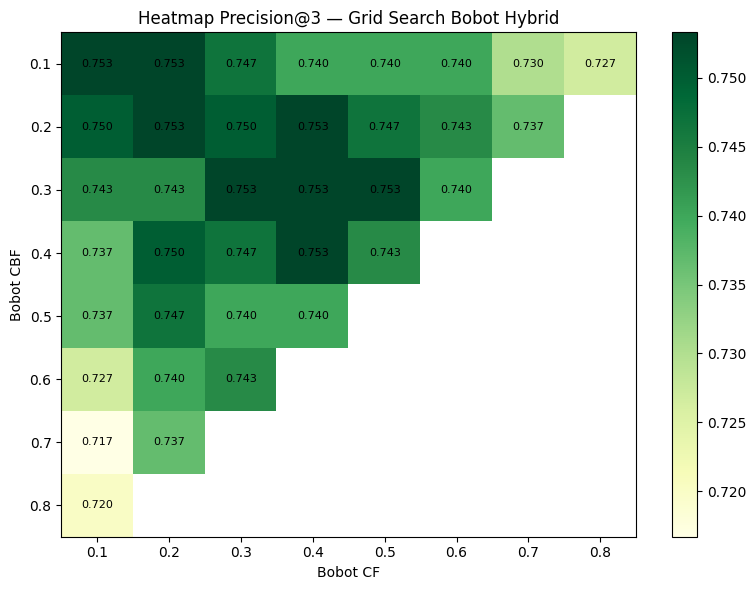

In [8]:
# Visualisasi grid search
grid_df = pd.DataFrame(results_grid).sort_values('precision_at_k', ascending=False)
print('Top 10 kombinasi bobot:')
print(grid_df.head(10).to_string(index=False))

# Heatmap CBF vs CF (KB = sisa)
pivot = grid_df.pivot_table(
    index='cbf', columns='cf', values='precision_at_k', aggfunc='max'
)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'{v:.1f}' for v in pivot.columns])
ax.set_yticklabels([f'{v:.1f}' for v in pivot.index])
ax.set_xlabel('Bobot CF')
ax.set_ylabel('Bobot CBF')
ax.set_title(f'Heatmap Precision@{K_TARGET} — Grid Search Bobot Hybrid')
plt.colorbar(im, ax=ax)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Simpan bobot terbaik

In [9]:
save_weights(best_weights)
print(f'Bobot disimpan: {best_weights}')

[hybrid] Weights disimpan: c:\Users\USER\Downloads\pdm_recommendation\pdm_recommendation\notebooks\..\models\weights_config.json
Bobot disimpan: {'cbf': np.float64(0.1), 'cf': np.float64(0.1), 'kb': np.float64(0.8)}


## 7. Evaluasi hybrid final dengan bobot terbaik

In [10]:
print('Evaluasi hybrid dengan bobot terbaik...')
eval_rows = []

for mid in all_machine_ids:
    sensor, days = get_latest_state(mid)
    try:
        recs = hybrid_recommend(
            mid, interaction, sim_cbf, sim_cf,
            sensor, days, top_k=5, weights=best_weights
        )
        rec_list = recs['comp'].tolist()
        for k in EVAL_K_VALUES:
            p  = precision_at_k(mid, rec_list, ground_truth, k)
            r  = recall_at_k(mid, rec_list, ground_truth, k)
            f1 = (2*p*r/(p+r)) if (p+r) > 0 else 0
            eval_rows.append({
                'machineID': mid, 'k': k,
                'precision': round(p, 4),
                'recall'   : round(r, 4),
                'f1'       : round(f1, 4),
            })
    except Exception as e:
        print(f'  Skip mesin {mid}: {e}')

eval_df = pd.DataFrame(eval_rows)

# Simpan ke CSV untuk ditampilkan di dashboard
eval_path = MODEL_FILES['weights'].parent / 'evaluation_results.csv'
eval_df.to_csv(eval_path, index=False)
print(f'Hasil evaluasi disimpan: {eval_path}')

print_evaluation_summary(eval_df)

Evaluasi hybrid dengan bobot terbaik...
Hasil evaluasi disimpan: c:\Users\USER\Downloads\pdm_recommendation\pdm_recommendation\notebooks\..\models\evaluation_results.csv

RINGKASAN EVALUASI SISTEM
   precision  recall     f1
k                          
1     0.8200  0.3167 0.4477
3     0.7533  0.8683 0.7863
5     0.5200  0.9800 0.6646


## 8. Visualisasi evaluasi final

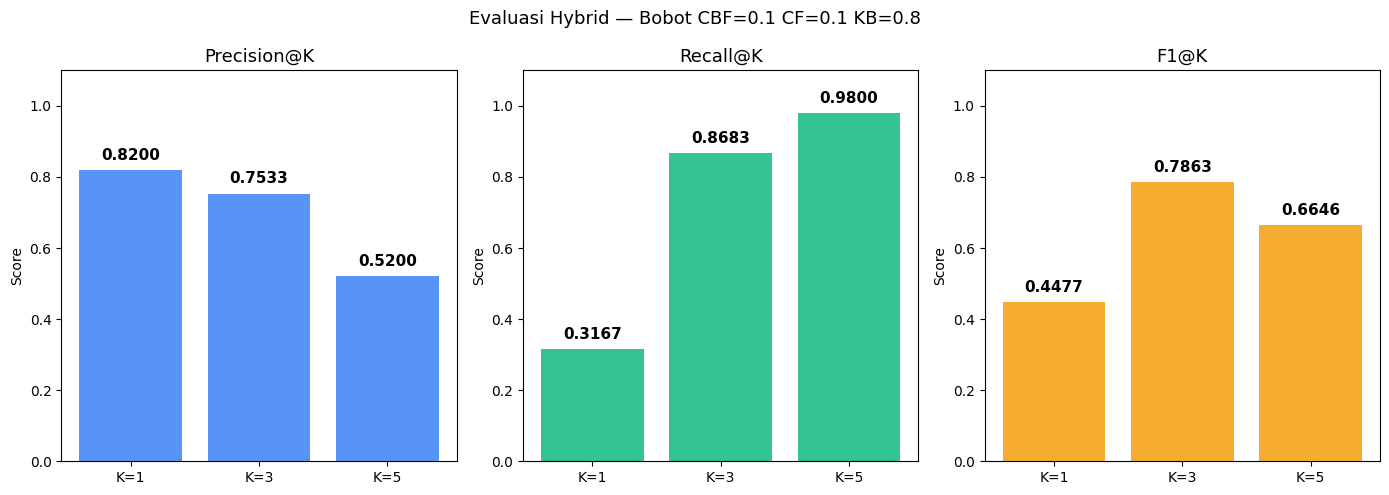

Chart disimpan ke models/evaluation_chart.png


In [11]:
summary = eval_df.groupby('k')[['precision', 'recall', 'f1']].mean().round(4)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['precision', 'recall', 'f1']
colors  = ['#3B82F6', '#10B981', '#F59E0B']
titles  = ['Precision@K', 'Recall@K', 'F1@K']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    bars = ax.bar([f'K={k}' for k in EVAL_K_VALUES],
                  summary[metric], color=color, alpha=0.85)
    ax.set_title(title, fontsize=13)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, summary[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle(
    f'Evaluasi Hybrid — Bobot CBF={best_weights["cbf"]} '
    f'CF={best_weights["cf"]} KB={best_weights["kb"]}',
    fontsize=13
)
plt.tight_layout()
plt.savefig(MODEL_FILES['weights'].parent / 'evaluation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart disimpan ke models/evaluation_chart.png')

## 9. Perbandingan metode individual vs hybrid

Perbandingan semua metode @ K=3:
        precision  recall     f1
Metode                          
CBF        0.7033  0.8050 0.7320
CF         0.7200  0.8300 0.7510
KB         0.7333  0.8533 0.7683
Hybrid     0.7533  0.8683 0.7863


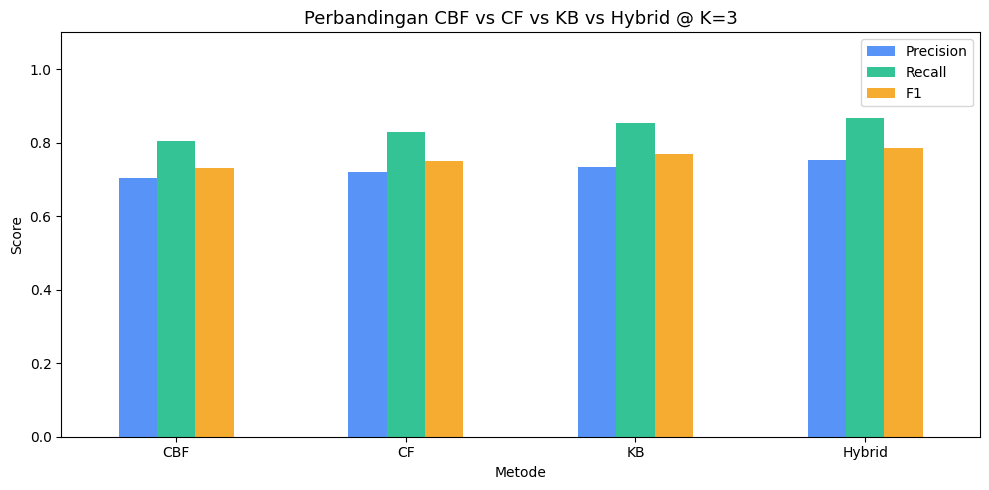

In [12]:
# Ringkasan perbandingan semua metode di K=3
k3_individual = (
    summary_individual
    .xs(3, level='k')
    .reset_index()
    .rename(columns={'method': 'Metode'})
)
k3_hybrid = pd.DataFrame([{
    'Metode'   : 'Hybrid',
    'precision': summary.loc[3, 'precision'],
    'recall'   : summary.loc[3, 'recall'],
    'f1'       : summary.loc[3, 'f1'],
}])
comparison_final = pd.concat([k3_individual, k3_hybrid]).set_index('Metode')

print('Perbandingan semua metode @ K=3:')
print(comparison_final)

# Plot
ax = comparison_final.plot(kind='bar', figsize=(10, 5), alpha=0.85,
                            color=['#3B82F6', '#10B981', '#F59E0B'])
ax.set_title('Perbandingan CBF vs CF vs KB vs Hybrid @ K=3', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(['Precision', 'Recall', 'F1'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Contoh rekomendasi untuk beberapa mesin

In [13]:
sample_machines = [1, 5, 10, 50]

for mid in sample_machines:
    sensor, days = get_latest_state(mid)
    recs = hybrid_recommend(
        mid, interaction, sim_cbf, sim_cf,
        sensor, days, top_k=3, weights=best_weights
    )
    gt = ground_truth.get(mid, set())
    hits = [c for c in recs['comp'].tolist() if c in gt]
    print(f'\nMesin {mid:3d} | Rekomendasi: {recs["comp"].tolist()} '
          f'| Ground truth: {gt} | Hit: {hits}')


Mesin   1 | Rekomendasi: ['comp1', 'comp4', 'comp2'] | Ground truth: {'comp2', 'comp1', 'comp4'} | Hit: ['comp1', 'comp4', 'comp2']

Mesin   5 | Rekomendasi: ['comp1', 'comp4', 'comp2'] | Ground truth: {'comp2', 'comp1'} | Hit: ['comp1', 'comp2']

Mesin  10 | Rekomendasi: ['comp2', 'comp4', 'comp3'] | Ground truth: {'comp2', 'comp1'} | Hit: ['comp2']

Mesin  50 | Rekomendasi: ['comp3', 'comp1', 'comp2'] | Ground truth: {'comp2', 'comp1'} | Hit: ['comp1', 'comp2']
